# COKLU DOGRUSAL REGRESYON:ÜSKÜDAR EMLAK PİYASASI İÇİN TAHMİN VE DEĞERLEME

In [33]:
#kutuphaneleri indireim.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as seabornInstance
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.metrics import r2_score
%matplotlib inline


In [27]:
#veri setini indiirp ilk 5ini görüntülüyoruz.
veri=pd.read_excel("https://www.dropbox.com/s/luoopt5biecb04g/SATILK_EV1.xlsx?dl=1",index_col=0)#fiyat 3 sıfır kısaltlmıştır.
veri.head()#ilk 5 i verir

,Fiyat,Oda_Sayısı,Net_m2,Katı,Yaşı
0,475,1,40,0,6
1,475,1,55,0,5
2,450,1,50,0,7
3,450,1,55,1,6
4,475,1,45,2,7


In [7]:
print("\nBOYUT: ",veri.shape )   #veri  serinin boyutuna bakalım:
print("\n\nISTATISTIK OZETLER: \n",veri.describe())    #istatistik özetlerine bakalım
print("\n\nEKSIK VAR MI KONTROL: \n",veri.isnull().any())  # eksik var mı diye kontrol edelim.


BOYUT:  (191, 5)


ISTATISTIK OZETLER: 
              Fiyat  Oda_Sayısı      Net_m2        Katı        Yaşı
count   191.000000  191.000000  191.000000  191.000000  191.000000
mean    649.476440    2.340314   85.183246    3.931937   12.753927
std     111.064174    0.721401   16.482620    3.752974    8.374596
min     450.000000    1.000000   40.000000    0.000000    0.000000
25%     575.000000    2.000000   80.000000    0.000000    4.000000
50%     650.000000    2.000000   90.000000    3.000000   16.000000
75%     700.000000    3.000000   95.000000    7.000000   20.000000
max    1175.000000    3.000000  125.000000   11.000000   24.000000


EKSIK VAR MI KONTROL: 
 Fiyat         False
Oda_Sayısı    False
Net_m2        False
Katı          False
Yaşı          False
dtype: bool


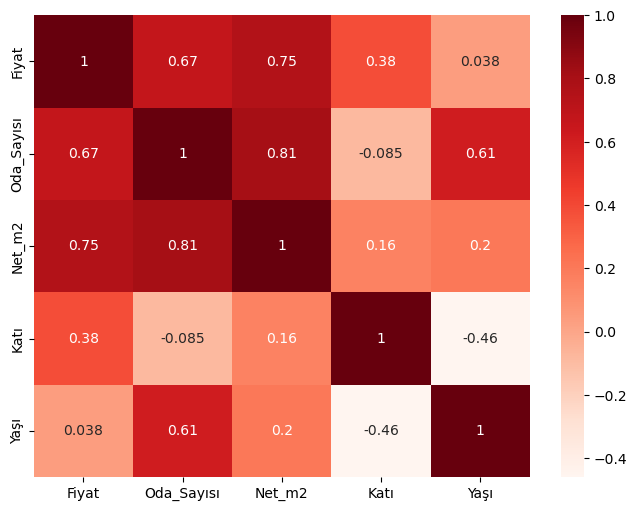

In [19]:
#veri serindeki tüm degiskelerin kendi aralarındaki korelasyonlarını gorsellestirelim:
plt.figure(figsize=(8,6))
cor=veri.corr()
sns.heatmap(cor,annot=True,cmap=plt.cm.Reds)
plt.show()

<Axes: xlabel='Yaşı', ylabel='Count'>

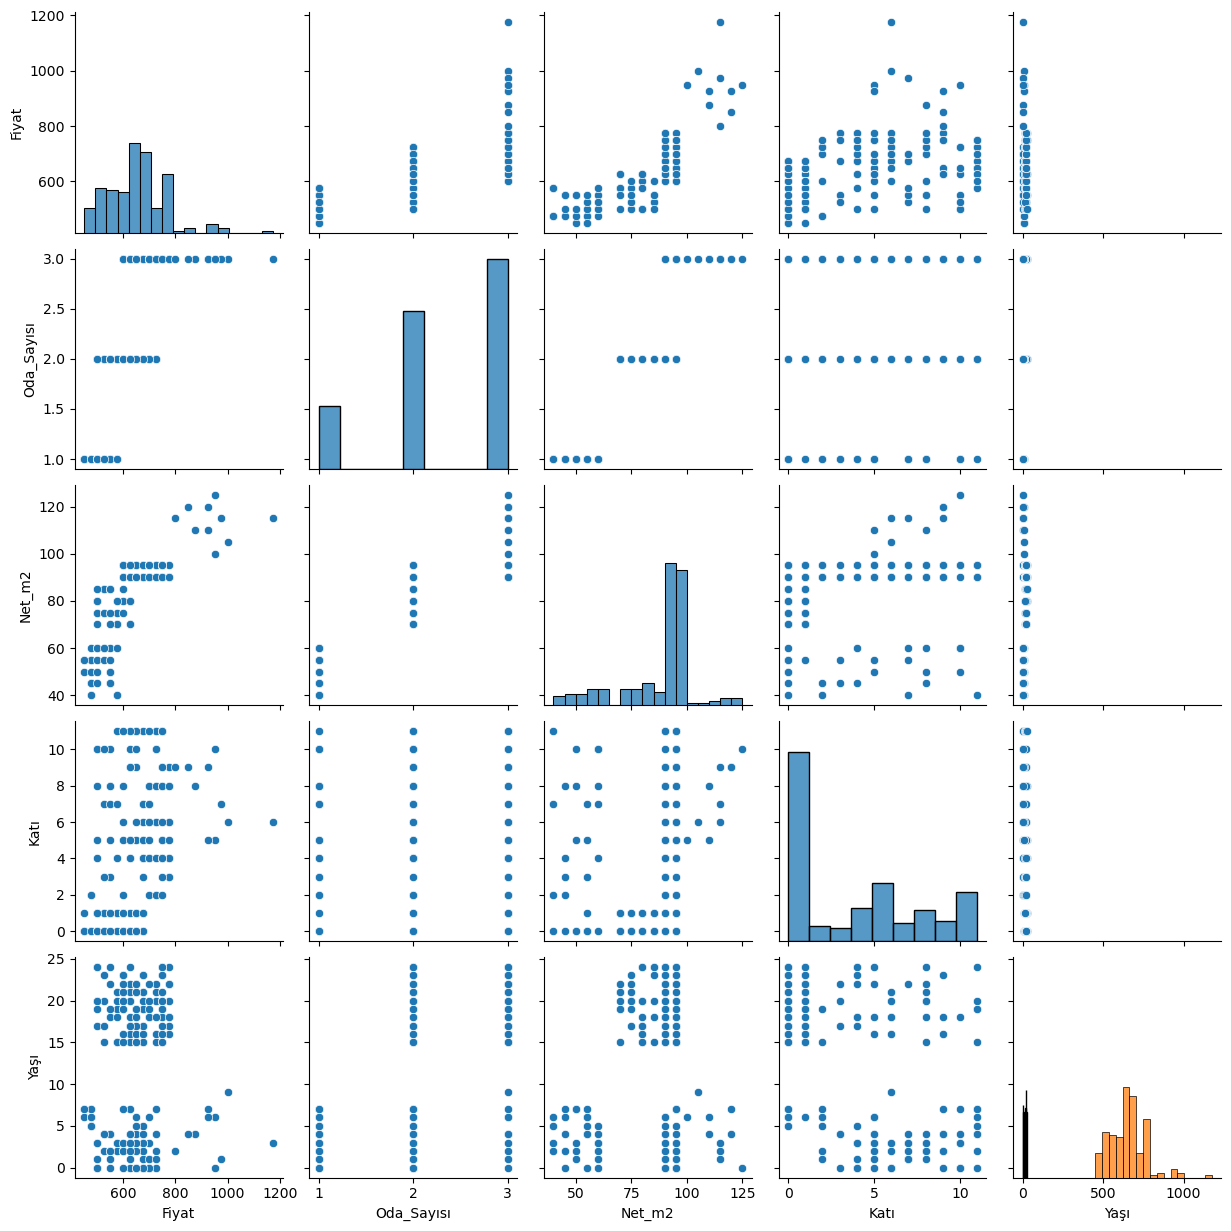

In [9]:
#tum degiskenlerin birbirileri ile olan serpilme diyagramlarına bakalım
sns.pairplot(veri)
#hedef degiskeni olan Fiyat degiskeni dagılımına bakalım.
sns.histplot(veri["Fiyat"]) #distplot eskidendi

In [13]:
#hedeff (y) ve öznitelik(x) tanımlayalım:
x= veri[["Oda_Sayısı","Net_m2","Katı","Yaşı"]]
y= veri["Fiyat"]

In [17]:
#model test ve egitim oranını belirliyoruz.
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [19]:
#algoritmayı eğitiyoruz.
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [25]:
#sabit ve öznitelik değişkenlerin tahmin edilen parametrelere bakalım.
print(model.intercept_)#sabit değişken bir denlemdeki başlangç fiyatı gibi düşün

coeff_df=pd.DataFrame(model.coef_,x.columns,columns=["Öznitelik_katsayıları"])##bunlarda özniteliklerin katsayıarıdır,denklemdeki her değerin önündeki çarpan sayısı
print(coeff_df)

305.16258952877524
            Öznitelik_katsayıları
Oda_Sayısı             118.350670
Net_m2                   1.133092
Katı                     7.096886
Yaşı                    -4.665706


In [29]:
#eğitim veri seti için tahmin değerleri karşılaştırma
y_pred_egitim=model.predict(x_train)
for i,prediction in enumerate(y_pred_egitim):
    print(f"Tahmin edilen Ev fiyatı:{prediction},Gerçek ev Fiyatı: {y[i]}")
    

Tahmin edilen Ev fiyatı:551.9595135495705,Gerçek ev Fiyatı: 475
Tahmin edilen Ev fiyatı:686.306810238324,Gerçek ev Fiyatı: 475
Tahmin edilen Ev fiyatı:531.2971800332684,Gerçek ev Fiyatı: 450
Tahmin edilen Ev fiyatı:694.6384690155814,Gerçek ev Fiyatı: 450
Tahmin edilen Ev fiyatı:675.6606940961011,Gerçek ev Fiyatı: 475
Tahmin edilen Ev fiyatı:698.3827786103968,Gerçek ev Fiyatı: 475
Tahmin edilen Ev fiyatı:558.2916643459344,Gerçek ev Fiyatı: 475
Tahmin edilen Ev fiyatı:678.2101700257285,Gerçek ev Fiyatı: 475
Tahmin edilen Ev fiyatı:546.2940531752715,Gerçek ev Fiyatı: 450
Tahmin edilen Ev fiyatı:680.838003156766,Gerçek ev Fiyatı: 475
Tahmin edilen Ev fiyatı:845.060750038195,Gerçek ev Fiyatı: 475
Tahmin edilen Ev fiyatı:546.2940531752715,Gerçek ev Fiyatı: 525
Tahmin edilen Ev fiyatı:746.9445057016595,Gerçek ev Fiyatı: 550
Tahmin edilen Ev fiyatı:562.4676457981525,Gerçek ev Fiyatı: 575
Tahmin edilen Ev fiyatı:553.1942861046792,Gerçek ev Fiyatı: 550
Tahmin edilen Ev fiyatı:693.2070431677317,G

In [37]:
#eğitim veri seti değerleri için r2 ye bakalım.
r2_score(y_train,y_pred_egitim)


0.733739961656849

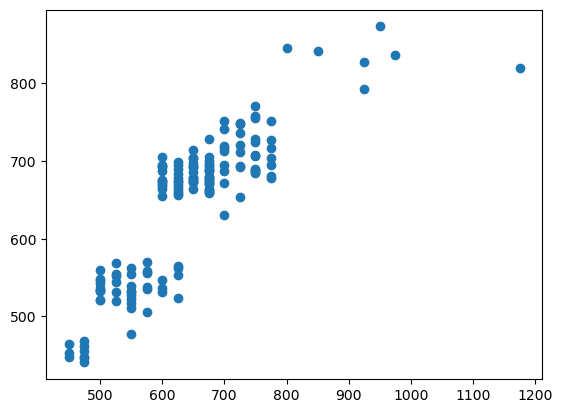

In [39]:
#eğitim verisideki fiyatların gerçek ve tahmin edilen değer grafiği:serpilme grafiği
plt.scatter(y_train,y_pred_egitim)


In [41]:
#test veri seti ile tahmin edielen değerleri karşılaştırma
y_pred_test=model.predict(x_test)
for i,prediction in enumerate(y_pred_test):
    print(f"Tahmin edilen Ev Fiyatı:{prediction},Gerçek Ev Fiyatı:{y[i]}")

Tahmin edilen Ev Fiyatı:706.5977149143232,Gerçek Ev Fiyatı:475
Tahmin edilen Ev Fiyatı:654.3700354296552,Gerçek Ev Fiyatı:475
Tahmin edilen Ev Fiyatı:747.7476063993654,Gerçek Ev Fiyatı:450
Tahmin edilen Ev Fiyatı:692.285646378695,Gerçek Ev Fiyatı:450
Tahmin edilen Ev Fiyatı:720.4765379745486,Gerçek Ev Fiyatı:475
Tahmin edilen Ev Fiyatı:537.5712777554012,Gerçek Ev Fiyatı:475
Tahmin edilen Ev Fiyatı:459.70218260450696,Gerçek Ev Fiyatı:475
Tahmin edilen Ev Fiyatı:521.3177543131103,Gerçek Ev Fiyatı:475
Tahmin edilen Ev Fiyatı:669.8785112484711,Gerçek Ev Fiyatı:450
Tahmin edilen Ev Fiyatı:686.306810238324,Gerçek Ev Fiyatı:475
Tahmin edilen Ev Fiyatı:682.8758764095808,Gerçek Ev Fiyatı:475
Tahmin edilen Ev Fiyatı:720.7914873586205,Gerçek Ev Fiyatı:525
Tahmin edilen Ev Fiyatı:488.4611563334046,Gerçek Ev Fiyatı:550
Tahmin edilen Ev Fiyatı:725.6538470352135,Gerçek Ev Fiyatı:575
Tahmin edilen Ev Fiyatı:686.306810238324,Gerçek Ev Fiyatı:550
Tahmin edilen Ev Fiyatı:781.0139984912952,Gerçek Ev Fiyat

In [43]:
#fiyat test verilerini r2_score bakalım.
r2_score(y_test,y_pred_test)

0.6987282352837989

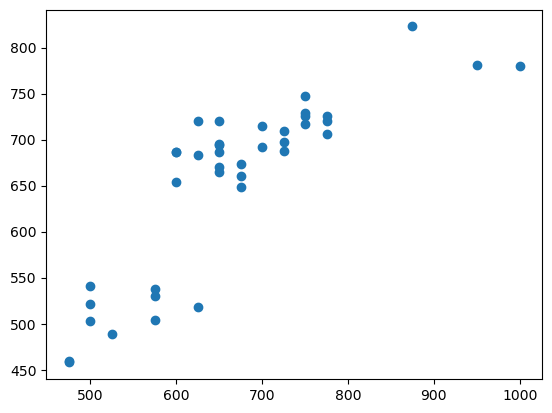

In [45]:
#test fiyat verilerini tahöin edilen ile serpilme grafiği:
plt.scatter(y_test,y_pred_test)

In [65]:
#2+1 odalı ,8 yıllık bir binanın 4.katında bulunan 105 m2 olan bir dairenin fiyatını tahmin edelim.
yeni_ev_df = pd.DataFrame([[3, 120, 5, 10]], 
                          columns=["Oda_Sayısı", "Net_m2", "Katı", "Yaşı"])

tahmin = model.predict(yeni_ev_df)
print(tahmin)

[785.01301445]
